In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import root_scalar

# ==========================================
# 1. PARÁMETROS FÍSICOS Y CONSTANTES
# ==========================================
theta = np.radians(34.0)          # Ángulo de mezcla en vacío (34 grados a radianes)
cos2theta = np.cos(2 * theta)
sin2theta = np.sin(2 * theta)
k = sin2theta**2

# El parámetro 'c' agrupa: (2 * sqrt(2) * G_F * N_e) / Delta_m^2
# Para el núcleo solar, este valor suele situar la resonancia (E_res) alrededor de los 2 MeV.
# Unidades de c: [MeV^-1]
c = 0.187 

# ==========================================
# 2. FUNCIONES ANALÍTICAS
# ==========================================
def prob_supervivencia(E):
    """Calcula la probabilidad P_ee en función de la energía E (en MeV)"""
    u = cos2theta - c * E
    cos2theta_m = u / np.sqrt(u**2 + k)
    return 0.5 * (1 + cos2theta * cos2theta_m)

def derivada_absoluta(E):
    """Calcula el valor absoluto de dP_ee/dE analíticamente"""
    u = cos2theta - c * E
    # Usamos la fórmula exacta que derivamos antes
    deriv = -0.5 * c * cos2theta * k / (u**2 + k)**1.5
    return abs(deriv)


In [ ]:
# ==========================================
# 3. CÁLCULO DE LOS PUNTOS CRÍTICOS (CRITERIO FÍSICO DE AMPLITUD)
# ==========================================
# A) Encontramos la Resonancia
E_res = cos2theta / c

# B) Calculamos las dos mesetas asintóticas
P_vacio = prob_supervivencia(0.0)      # Límite E -> 0
P_materia = prob_supervivencia(1000.0) # Límite E -> inf (ponemos 1000 MeV para asegurar)
caida_total = P_vacio - P_materia

tolerancia = 0.05

# C) Definimos los umbrales físicos (5% y 95% de la transición)
umbral_start = P_vacio - tolerancia * caida_total
umbral_end = P_materia + tolerancia * caida_total

def func_start(E):
    return prob_supervivencia(E) - umbral_start

def func_end(E):
    return prob_supervivencia(E) - umbral_end

# D) Buscamos las raíces exactas (ahora con valores positivos seguros)
raiz_izq = root_scalar(func_start, bracket=[0.0, E_res])
E_start = raiz_izq.root

raiz_der = root_scalar(func_end, bracket=[E_res, 50.0])
E_end = raiz_der.root

# ==========================================
#  42. CALCULOS PARA COMPARAR
# ==========================================

Pee_vacio=1-0.5*sin2theta**2

Pee_infinito=np.sin(theta)**2




--------------------------------------------------
ANÁLISIS DE LA TRANSICIÓN MSW (NÚCLEO SOLAR)
--------------------------------------------------
-> Energía de Resonancia (Punto de inflexión): 2.00 MeV
-> E_start (Comienza a notar la materia)    : 0.41 MeV
-> E_end   (Se estabiliza en la meseta)      : 14.68 MeV
--------------------------------------------------
P_ee en E_start (E -> 0)  : 0.557
P_ee en E_end (E -> inf): 0.326
P_ee en E_res (E -> inf): 0.500
P_ee en el vacío analítica (E -> 0)  : 0.570
P_ee en materia analítica (E -> inf): 0.313
--------------------------------------------------


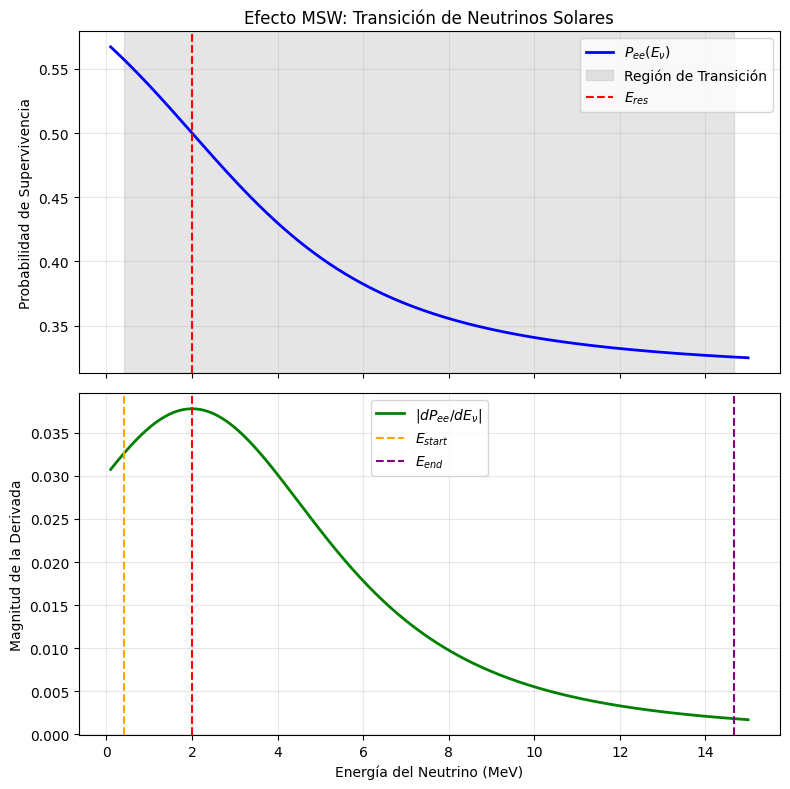

In [ ]:
# ==========================================
# 4. IMPRIMIR RESULTADOS POR PANTALLA
# ==========================================
print("-" * 50)
print("ANÁLISIS DE LA TRANSICIÓN MSW (NÚCLEO SOLAR)")
print("-" * 50)
print(f"-> Energía de Resonancia (Punto de inflexión): {E_res:.2f} MeV")
print(f"-> E_start (Comienza a notar la materia)    : {E_start:.2f} MeV")
print(f"-> E_end   (Se estabiliza en la meseta)      : {E_end:.2f} MeV")
print("-" * 50)
print(f"P_ee en E_start (E -> 0)  : {prob_supervivencia(E_start):.3f}")
print(f"P_ee en E_end (E -> inf): {prob_supervivencia(E_end):.3f}")
print(f"P_ee en E_res (E -> inf): {prob_supervivencia(E_res):.3f}")
print(f"P_ee en el vacío analítica (E -> 0)  : {Pee_vacio:.3f}")
print(f"P_ee en materia analítica (E -> inf): {Pee_infinito:.3f}")
print("-" * 50)

# ==========================================
# 5. GENERACIÓN DE GRÁFICAS PARA EL TFM
# ==========================================
energias = np.linspace(0.1, 15, 500)
p_ee = prob_supervivencia(energias)
dP_dE = derivada_absoluta(energias)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

# Gráfica Superior: Probabilidad
ax1.plot(energias, p_ee, 'b-', lw=2, label=r'$P_{ee}(E_\nu)$')
ax1.axvspan(E_start, E_end, color='gray', alpha=0.2, label='Región de Transición')
ax1.axvline(E_res, color='red', linestyle='--', label=r'$E_{res}$')
ax1.set_ylabel('Probabilidad de Supervivencia')
ax1.set_title('Efecto MSW: Transición de Neutrinos Solares')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Gráfica Inferior: Derivada
ax2.plot(energias, dP_dE, 'g-', lw=2, label=r'$|dP_{ee}/dE_\nu|$')
ax2.axvline(E_start, color='orange', linestyle='--', label=r'$E_{start}$')
ax2.axvline(E_end, color='purple', linestyle='--', label=r'$E_{end}$')
ax2.axvline(E_res, color='red', linestyle='--')
ax2.set_xlabel('Energía del Neutrino (MeV)')
ax2.set_ylabel('Magnitud de la Derivada')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()